In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(url, sep=";")  

df.head()
print(df.isnull().sum())
df = df.dropna()

df["is_good"] = (df["quality"] > 6).astype(int)
vinos_fuertes = df[df["alcohol"] > 11]

print(vinos_fuertes.head())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
     fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
45             4.6              0.52         0.15             2.1      0.054   
95             4.7              0.60         0.17             2.3      0.058   
131            5.6              0.50         0.09             2.3      0.049   
132            5.6              0.50         0.09             2.3      0.049   
142            5.2              0.34         0.00             1.8      0.050   

     free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
45                   8.0                  65.0   0.9934  3.90       0.56   
95                  17.0                 1

In [8]:
X = df.drop(columns=["quality", "is_good"]).values
media = np.mean(X, axis=0)
desv = np.std(X, axis=0)

print(media)
print(desv)
X_normalizado = (X - media) / desv

[ 8.31963727  0.52782051  0.27097561  2.5388055   0.08746654 15.87492183
 46.46779237  0.99674668  3.3111132   0.65814884 10.42298311]
[1.74055180e+00 1.79003704e-01 1.94740214e-01 1.40948711e+00
 4.70505826e-02 1.04568856e+01 3.28850367e+01 1.88674370e-03
 1.54338181e-01 1.69453967e-01 1.06533430e+00]


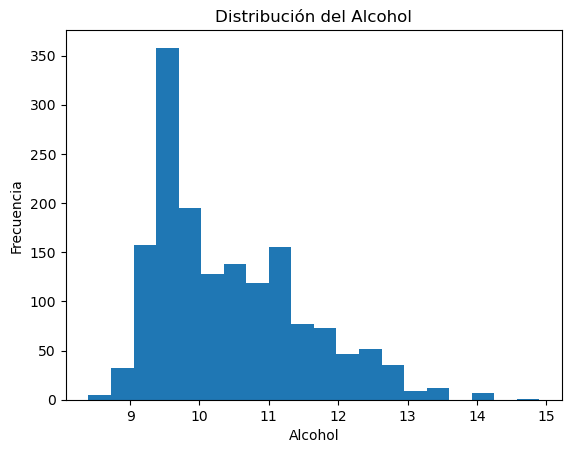

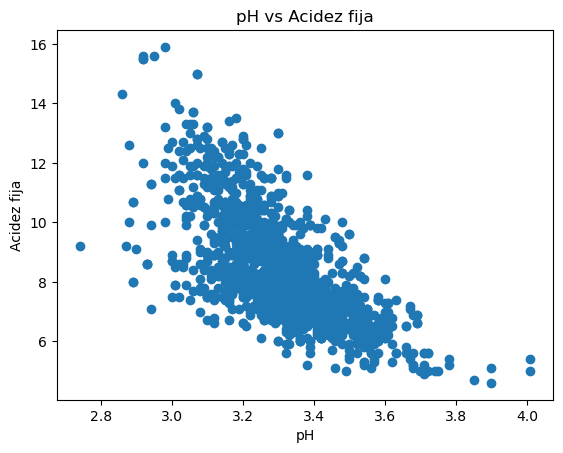

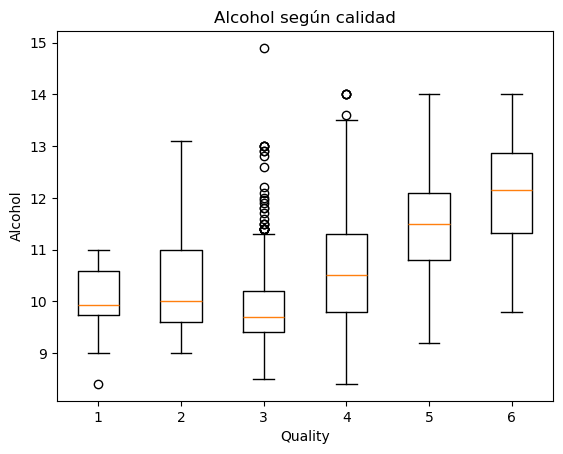

In [6]:
plt.hist(df["alcohol"], bins=20)
plt.title("Distribución del Alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Frecuencia")
plt.show()

plt.scatter(df["pH"], df["fixed acidity"])
plt.xlabel("pH")
plt.ylabel("Acidez fija")
plt.title("pH vs Acidez fija")
plt.show()

plt.boxplot([df[df["quality"] == q]["alcohol"] for q in sorted(df["quality"].unique())])

plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.title("Alcohol según calidad")
plt.show()


In [3]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"

penguins = pd.read_csv(url)

print(penguins.head())
print(penguins.isnull().sum())
penguins = penguins.dropna(subset=["body_mass_g","bill_length_mm","bill_depth_mm"])

promedios = penguins.groupby(["species","island"])["body_mass_g"].mean()

print(promedios)

gentoo_pesados = penguins[
    (penguins["species"] == "Gentoo") &
    (penguins["body_mass_g"] > 5000)
]

print(gentoo_pesados)

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3          NaN     NaN  
4       3450.0  FEMALE  
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64
species    island   
Adelie     Biscoe       3709.659091
           Dream        3688.392857
           Torgersen    3706.372549
Chinstrap  Dream        3733.088235
Gentoo     Biscoe       5076.016260
Name: body_mass_g, dtyp

In [14]:
matriz = penguins[["bill_length_mm","bill_depth_mm"]].values
proporcion = matriz[:,0] / matriz[:,1]

largo = matriz[:,0]

media = np.mean(largo)
desv = np.std(largo)

outliers = largo[np.abs(largo - media) > 2*desv]

print(outliers)

pares = matriz[::2]

print(pares)

[32.1 58.  55.8 59.6 55.9 55.1]


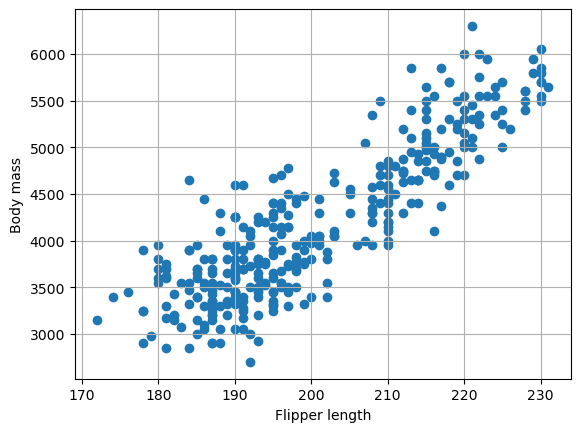

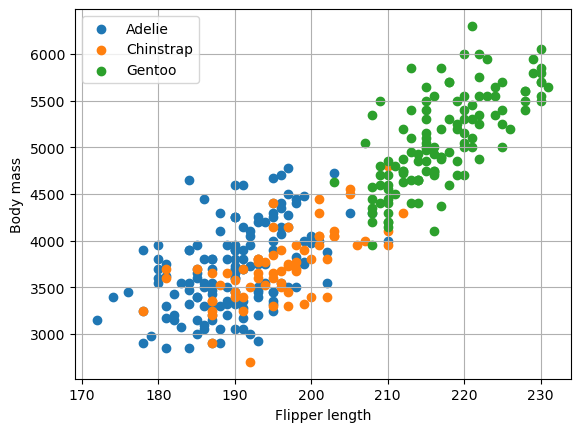

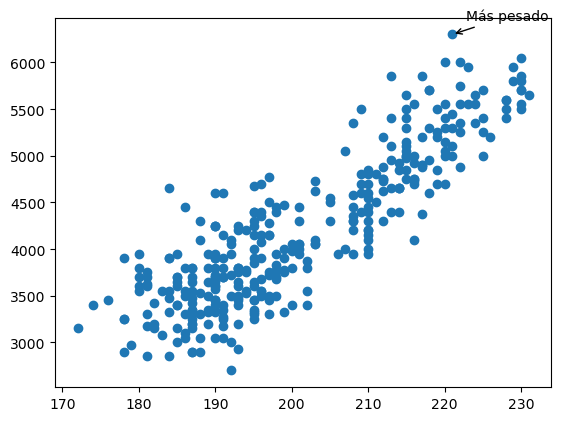

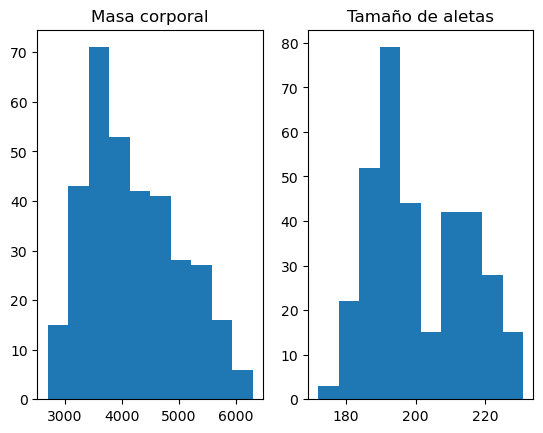

In [20]:
plt.scatter(penguins["flipper_length_mm"], penguins["body_mass_g"])
plt.xlabel("Flipper length")
plt.ylabel("Body mass")
plt.grid(True)
plt.show()

species = penguins["species"].unique()

for sp in species:
    subset = penguins[penguins["species"] == sp]
    
    plt.scatter(
        subset["flipper_length_mm"],
        subset["body_mass_g"],
        label=sp
    )

plt.legend()
plt.xlabel("Flipper length")
plt.ylabel("Body mass")
plt.grid(True)
plt.show()

max_idx = penguins["body_mass_g"].idxmax()

heaviest = penguins.loc[max_idx]

plt.scatter(penguins["flipper_length_mm"], penguins["body_mass_g"])

plt.annotate(
    "Más pesado",
    (heaviest["flipper_length_mm"], heaviest["body_mass_g"]),
    xytext=(10,10),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.show()

fig, ax = plt.subplots(1,2)

ax[0].hist(penguins["body_mass_g"])
ax[0].set_title("Masa corporal")

ax[1].hist(penguins["flipper_length_mm"])
ax[1].set_title("Tamaño de aletas")

plt.show()